## Question: What distinct purchase patterns exist, and do they show up in different proportions across stores?

In [1]:
import pandas as pd
import numpy as np                                  #fast math on arrays; helps with things like log transforms
from sklearn.preprocessing import StandardScaler    #puts features on the same scale before clustering
from sklearn.cluster import KMeans                  #the algorithm that groups similar transactions
from sklearn.decomposition import PCA               #squashes many features into 2 for the scatter plot
import matplotlib.pyplot as plt                     #quick sanity-check plots inside VS Code

In [2]:
df = pd.read_excel(r"C:\Users\vesna\Desktop\Neuefische\MyWork\Coffee+Shop+Sales\Coffee Shop Sales.xlsx")

In [3]:
df.shape

(149116, 11)

In [4]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

In [5]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [6]:
df['transaction_id'].nunique(), len(df)   #checking whether 1 row is a whole transaction or a single product line, this decides if I cluster rows directly or aggregate first.

(149116, 149116)

In [7]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[us]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
dtype: object

## Feature Engineering

KMeans groups by distance, so features must be numeric and meaningful. 
Using 4: hour, is_weekend, transaction_qty, unit_price

In [8]:
df['hour'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S').dt.hour

In [9]:
df['hour'].head()

0    7
1    7
2    7
3    7
4    7
Name: hour, dtype: int32

In [10]:
df['is_weekend'] = (pd.to_datetime(df['transaction_date']).dt.dayofweek >= 5).astype(int)

In [11]:
df['is_weekend'].value_counts()

is_weekend
0    107510
1     41606
Name: count, dtype: int64

In [12]:
df[['hour', 'transaction_qty', 'unit_price', 'is_weekend']].describe()

,hour,transaction_qty,unit_price,is_weekend
count,149116.000000,149116.000000,149116.000000,149116.000000
mean,11.735790,1.438276,3.382219,0.279018
std,3.764662,0.542509,2.658723,0.448518
min,6.000000,1.000000,0.800000,0.000000
25%,9.000000,1.000000,2.500000,0.000000
50%,11.000000,1.000000,3.000000,0.000000
75%,15.000000,2.000000,3.750000,1.000000
max,20.000000,8.000000,45.000000,1.000000


All 4 features valid. 

A difference 40 in unit_price looks large to the algorithm, while a jump from weekday to weekend (a difference of 1) looks very small. So without scaling, KMeans would cluster almost entirely on price and basically ignore weekend and quantity — not because price matters more, but because its numbers happen to be bigger.

## Scaling

Features are on very different ranges (price up to 45, weekend just 0–1). 
Scaling gives each an equal opportunity so KMeans doesn't cluster mostly on price.

In [13]:
features = ['hour', 'transaction_qty', 'unit_price', 'is_weekend']
X = df[features]

In [14]:
X.shape

(149116, 4)

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
X_scaled[:5]

array([[-1.25796315,  1.03542224, -0.14376103,  1.60748322],
       [-1.25796315,  1.03542224, -0.10614885,  1.60748322],
       [-1.25796315,  1.03542224,  0.42042157,  1.60748322],
       [-1.25796315, -0.80787213, -0.51988276,  1.60748322],
       [-1.25796315,  1.03542224, -0.10614885,  1.60748322]])

In [17]:
X_scaled.mean(axis=0).round(2)

array([ 0.,  0., -0.,  0.])

## KMeans

In [18]:
#Elbow method to find the optimal number of clusters

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

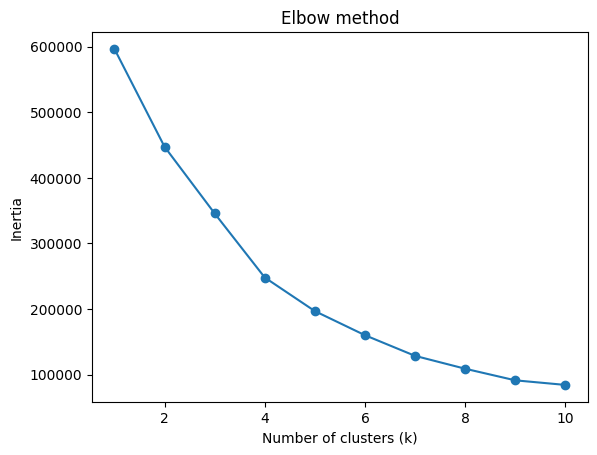

In [19]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()

k = 4

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
df['cluster'].value_counts()

cluster
1    61209
3    45571
0    40048
2     2288
Name: count, dtype: int64

Is no. 2 outlier or a niche? 

In [22]:
df.groupby('cluster')[['hour', 'transaction_qty', 'unit_price', 'is_weekend']].mean().round(2)

,hour,transaction_qty,unit_price,is_weekend
cluster,,,,
0,11.78,1.41,3.11,1.00
1,11.73,1.00,3.24,0.00
2,10.93,1.03,20.98,0.29
3,11.75,2.07,2.93,0.02


Cluster 2 is a niche indeed. unit_price: 20.98, vs around 3 for everyone else. That's around 7× price gap.

Transactions separate by what and how people buy (weekday single / weekday multi / weekend / premium), not by when. Hour means nothing here because transactions averages towards noon (7 am - 5 pm)

I will keep 4 anyway.

## Comparing clusters across shops 

In [23]:
pd.crosstab(df['store_location'], df['cluster'], normalize='index').round(3)

cluster,0,1,2,3
store_location,,,,
Astoria,0.273,0.422,0.014,0.291
Hell's Kitchen,0.275,0.411,0.016,0.298
Lower Manhattan,0.257,0.397,0.016,0.330


Patterns appear in nearly identical proportions across all three stores, with only Lower Manhattan showing a slight lean toward multi-item purchases.

In [24]:
#naming clusters 

cluster_names = {
    0: 'Weekend Purchase',
    1: 'Weekday Quick Grab',
    2: 'Premium / High-Spend',
    3: 'Weekday Multi-Buy'
}
df['cluster_name'] = df['cluster'].map(cluster_names)

In [25]:
df['cluster_name'].value_counts()

cluster_name
Weekday Quick Grab      61209
Weekday Multi-Buy       45571
Weekend Purchase        40048
Premium / High-Spend     2288
Name: count, dtype: int64

## Exporting to Tableau

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

In [28]:
pca.explained_variance_ratio_.sum().round(2)

np.float64(0.53)

In [29]:
df.to_csv('coffee_clusters_for_tableau.csv', index=False)